# Electricity demand recalibration for Libya (2015-2023)

This notebook aligns the total electricity consumption produced by the SISEPUEDE end-use sectors (INEN + SCOE + CCSQ + TRNS) with the **IEA historical electricity production** for Libya, on a year-by-year basis from 2015 through 2023.

## Source

[IEA - Libya: Total electricity production](https://www.iea.org/countries/libya/electricity) — 33,746 GWh in 2023. The full 2015-2023 series is stored at `ssp_modeling/input_data/reference/iea_libya_electricity_production.csv`.

## Logic

In SISEPUEDE, the end-use electricity consumption from INEN/SCOE/CCSQ/TRNS is what NemoMod must dispatch as *production* after accounting for transmission/distribution losses:

$$\text{production}_{y} = \frac{\text{end\_use\_demand}_{y}}{1 - \text{loss}_{y}}$$

So the model-side calibration target is:

$$\text{end\_use\_target}_{y} = \text{IEA\_production}_{y} \times (1 - \text{loss}_{y})$$

We treat **INEN and TRNS electricity as fixed** (they were calibrated elsewhere — INEN via `recalibrate_inen_energy_demand.ipynb`, TRNS is small) and close the gap by adjusting **SCOE appliance + heat scalars**:

$$f_{\text{SCOE}}^{y} = \frac{\text{end\_use\_target}_{y} - (\text{INEN\_elec}_{y} + \text{CCSQ\_elec}_{y} + \text{TRNS\_elec}_{y})}{\text{SCOE\_elec}_{y}}$$

`f_SCOE[y]` is written into the time-period rows of:

- `scalar_scoe_appliance_energy_demand_{residential,commercial_municipal,other_se}`
- `scalar_scoe_heat_energy_demand_{residential,commercial_municipal,other_se}`

For years outside 2015-2023 the scalar is left at its original value (default 1.0). Only SCOE is touched — INEN consumpinit columns from the previous notebook and all IPPU/transport inputs are preserved.

## Parameters

In [4]:
# Base CSV. Defaults to the INEN-recalibrated CSV so we stack both calibrations.
BASE_INPUT_CSV = "../../input_data/sisepuede_raw_inputs_LBY_apr_with_gfr.csv"

# Output CSV (overwrite the same file so downstream notebooks pick up both calibrations).
OUT_INPUT_CSV  = "../../input_data/sisepuede_raw_inputs_recalibrated_electricity.csv"

# IEA historical electricity production (GWh) - copied from
# https://www.iea.org/countries/libya/electricity on 2026-04-21.
IEA_CSV = "../../input_data/reference/iea_libya_electricity_production.csv"

# Calibration window
CALIB_YEAR_START = 2015
CALIB_YEAR_END   = 2023

# Base year (t=0) of the SISEPUEDE input
BASE_YEAR = 2015

# Terminal year of the input CSV (used to extend the post-calibration scalar)
TERMINAL_YEAR = 2050

# Strategy for scalar values AFTER CALIB_YEAR_END (removes the 1.0-reset cliff):
#   "hold"        - hold the CALIB_YEAR_END scalar flat through TERMINAL_YEAR
#                   (structural calibration: treat SCOE as systematically understated)
#   "linear_to_1" - linearly fade from the CALIB_YEAR_END value back to 1.0 over
#                   POST_CALIB_FADE_YEARS years, then stay at 1.0
#   "reset"       - leave original value (=1.0); produces a visible step at the boundary
POST_CALIB_STRATEGY = "hold"
POST_CALIB_FADE_YEARS = 10  # only used when POST_CALIB_STRATEGY == "linear_to_1"

# Transmission/distribution loss fraction for production -> end-use conversion.
# Set to None to read the column `frac_enfu_transmission_loss_fuel_electricity` from
# the CSV (per-year); set a scalar here to override with a constant value.
TRANSMISSION_LOSS_OVERRIDE = None

# Tolerance (fraction) for the per-year match assertion
REL_TOLERANCE = 0.01

# Clamp the SCOE scalar to keep physically plausible values
F_SCOE_MIN = 0.1
F_SCOE_MAX = 10.0

# Input region
REGION = "libya"

In [5]:
import os, sys, pathlib, warnings, logging
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

HERE = pathlib.Path(os.getcwd())
sys.path.insert(0, str(HERE.parent))
from utils.logger_utils import setup_clean_logger, mute_external_loggers
logger = setup_clean_logger('recalib', logging.INFO)
mute_external_loggers(['sisepuede'])

# 1 PJ = 1e15 J;  1 GWh = 3.6e12 J  ->  1 PJ = 1000/3.6 GWh
PJ_TO_GWH = 1000.0 / 3.6
GWH_TO_PJ = 3.6 / 1000.0

## 1. Load IEA historical and measure current SISEPUEDE electricity consumption

Runs the **EnergyConsumption** model only (INEN + SCOE + CCSQ + TRNS, no NemoMod) on the base input to obtain per-sector per-year electricity consumption. Converts to GWh and compares against the IEA series.

In [6]:
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
from ssp_transformations_handler.GeneralUtils import GeneralUtils

_EXAMPLES = sxl.SISEPUEDEExamples()

def run_energy_only(csv_path: str, y0: int = BASE_YEAR, y1: int = 2050) -> pd.DataFrame:
    """Run only the EnergyConsumption model (INEN+SCOE+CCSQ+TRNS), no NemoMod."""
    df_raw = pd.read_csv(csv_path)
    fs = sfs.SISEPUEDEFileStructure(initialize_directories=False)
    key_tp, key_year = fs.model_attributes.dim_time_period, fs.model_attributes.field_dim_year
    years = np.arange(y0, y1 + 1).astype(int)
    att_tp = att.AttributeTable(
        pd.DataFrame({key_tp: range(len(years)), key_year: years}), key_tp,
    )
    fs.model_attributes.update_dimensional_attribute_table(att_tp)
    matt = fs.model_attributes
    models = sm.SISEPUEDEModels(
        matt, allow_electricity_run=False,
        fp_julia=fs.dir_jl, fp_nemomod_reference_files=fs.dir_ref_nemo,
        initialize_julia=False,
    )
    df_ex = _EXAMPLES('input_data_frame')
    df = GeneralUtils().add_missing_cols(df_ex, df_raw.copy())
    df['region'] = REGION
    df = df[df['year'] <= y1]
    df_out = models.project(df, include_electricity_in_energy=False)
    df_out['year'] = df_out['time_period'].apply(lambda t: y0 + int(t))
    return df_out


def split_elec_by_sector(df_out: pd.DataFrame) -> pd.DataFrame:
    """Return a PJ/year dataframe with columns inen, scoe, ccsq, trns, total."""
    rows = []
    for _, row in df_out.iterrows():
        inen = float(row.get('energy_consumption_electricity_inen_total', 0.0))
        scoe = float(row.get('energy_consumption_electricity_scoe_total', 0.0))
        ccsq = float(row.get('energy_consumption_electricity_ccsq_total', 0.0))
        trns_cols = [c for c in df_out.columns
                     if c.startswith('energy_consumption_electricity_trns_')
                     and not c.endswith('_total')]
        trns = float(sum(row[c] for c in trns_cols))
        rows.append({'year': int(row['year']), 'inen': inen, 'scoe': scoe,
                     'ccsq': ccsq, 'trns': trns, 'total': inen+scoe+ccsq+trns})
    return pd.DataFrame(rows).sort_values('year').reset_index(drop=True)


# IEA historical
iea = pd.read_csv(IEA_CSV)
iea.columns = [c.strip() for c in iea.columns]
value_col = [c for c in iea.columns if 'electricity' in c.lower()][0]
iea = iea.rename(columns={value_col: 'iea_gwh'})[['Year', 'iea_gwh']].rename(columns={'Year': 'year'})
iea = iea[(iea['year'] >= CALIB_YEAR_START) & (iea['year'] <= CALIB_YEAR_END)].reset_index(drop=True)

# Current SISEPUEDE electricity consumption
df_out_base = run_energy_only(BASE_INPUT_CSV)
elec_base = split_elec_by_sector(df_out_base)
elec_base = elec_base[(elec_base['year'] >= CALIB_YEAR_START) & (elec_base['year'] <= CALIB_YEAR_END)].reset_index(drop=True)
elec_base['total_gwh'] = elec_base['total'] * PJ_TO_GWH

compare = iea.merge(elec_base, on='year')
compare['gap_gwh']  = compare['iea_gwh'] - compare['total_gwh']
compare['ratio']    = compare['iea_gwh'] / compare['total_gwh']

print('IEA vs current SISEPUEDE end-use electricity (GWh):')
print(compare[['year','iea_gwh','total_gwh','gap_gwh','ratio']].round(1).to_string(index=False))

No missing columns to add.
IEA vs current SISEPUEDE end-use electricity (GWh):
 year  iea_gwh  total_gwh  gap_gwh  ratio
 2015  44473.0    25376.1  19096.8    1.8
 2016  31202.6    24394.6   6808.1    1.3
 2017  35008.3    26589.0   8419.4    1.3
 2018  36905.8    28367.5   8538.3    1.3
 2019  37899.5    24638.0  13261.5    1.5
 2020  27503.8    16754.8  10749.0    1.6
 2021  38244.0    19721.6  18522.3    1.9
 2022  38953.1    19311.3  19641.7    2.0
 2023  35993.4    22134.9  13858.6    1.6


## 2. Compute per-year SCOE scalars and write them to the CSV

For each year y in [2015, 2023]:

1. Convert IEA production to end-use demand: `target_enduse[y] = iea_gwh[y] * (1 - loss[y]) * GWH_TO_PJ`.
2. Subtract the fixed INEN + CCSQ + TRNS electricity: `need_scoe[y] = target_enduse[y] - (inen+ccsq+trns)`.
3. Compute the SCOE scalar: `f_scoe[y] = need_scoe[y] / current_scoe[y]` (clamped to [`F_SCOE_MIN`, `F_SCOE_MAX`]).
4. Write `f_scoe[y]` into the six `scalar_scoe_{appliance,heat_energy}_energy_demand_*` columns at that year's `time_period` row.

In [7]:
SCOE_SCALAR_COLS = [
    'scalar_scoe_appliance_energy_demand_commercial_municipal',
    'scalar_scoe_appliance_energy_demand_other_se',
    'scalar_scoe_appliance_energy_demand_residential',
    'scalar_scoe_heat_energy_demand_commercial_municipal',
    'scalar_scoe_heat_energy_demand_other_se',
    'scalar_scoe_heat_energy_demand_residential',
]

df_in = pd.read_csv(BASE_INPUT_CSV)
missing = [c for c in SCOE_SCALAR_COLS if c not in df_in.columns]
assert not missing, f'Missing SCOE scalar columns in base CSV: {missing}'

# Resolve transmission loss per year (from CSV unless overridden)
if TRANSMISSION_LOSS_OVERRIDE is not None:
    loss_by_year = {y: float(TRANSMISSION_LOSS_OVERRIDE) for y in compare['year']}
else:
    loss_col = 'frac_enfu_transmission_loss_fuel_electricity'
    assert loss_col in df_in.columns, f'Column {loss_col} missing and no override provided'
    loss_by_year = {int(r['year']): float(r[loss_col]) for _, r in df_in.iterrows()}

# --- Compute per-year SCOE scalar inside the calibration window ---
rows = []
for _, row in compare.iterrows():
    y         = int(row['year'])
    iea_gwh_y = float(row['iea_gwh'])
    loss      = loss_by_year.get(y, 0.0)
    target_enduse_pj = iea_gwh_y * (1.0 - loss) * GWH_TO_PJ
    fixed_pj = float(row['inen'] + row['ccsq'] + row['trns'])
    need_scoe = target_enduse_pj - fixed_pj
    current_scoe = float(row['scoe'])
    if current_scoe <= 0:
        f = 1.0
    else:
        f = np.clip(need_scoe / current_scoe, F_SCOE_MIN, F_SCOE_MAX)
    rows.append({'year': y, 'iea_gwh': iea_gwh_y, 'loss': loss,
                 'target_enduse_pj': target_enduse_pj, 'fixed_pj': fixed_pj,
                 'current_scoe_pj': current_scoe, 'need_scoe_pj': need_scoe,
                 'f_scoe': f})
plan = pd.DataFrame(rows)

# --- Extend the scalar beyond CALIB_YEAR_END to avoid the 1.0-reset cliff ---
f_last = float(plan.loc[plan['year'] == CALIB_YEAR_END, 'f_scoe'].iloc[0])
post_rows = []
for y in range(CALIB_YEAR_END + 1, TERMINAL_YEAR + 1):
    if POST_CALIB_STRATEGY == "hold":
        f_post = f_last
    elif POST_CALIB_STRATEGY == "linear_to_1":
        step = (y - CALIB_YEAR_END)
        if step <= POST_CALIB_FADE_YEARS:
            f_post = f_last + (1.0 - f_last) * (step / POST_CALIB_FADE_YEARS)
        else:
            f_post = 1.0
    elif POST_CALIB_STRATEGY == "reset":
        f_post = 1.0
    else:
        raise ValueError(f'Unknown POST_CALIB_STRATEGY={POST_CALIB_STRATEGY!r}')
    post_rows.append({'year': y, 'f_scoe': f_post})
post_plan = pd.DataFrame(post_rows)

print(f'In-window SCOE scalar plan ({CALIB_YEAR_START}-{CALIB_YEAR_END}):')
print(plan[['year','iea_gwh','target_enduse_pj','current_scoe_pj','f_scoe']].round(4).to_string(index=False))
print(f"\nPost-window scalar (strategy={POST_CALIB_STRATEGY!r}, "
      f"{CALIB_YEAR_END+1}-{TERMINAL_YEAR}):")
print(post_plan.head(6).round(4).to_string(index=False), '...'
      if len(post_plan) > 6 else '')
print(f"  (values span {post_plan['f_scoe'].min():.4f} -> {post_plan['f_scoe'].max():.4f})")

# --- Write scalars into the CSV ---
year_to_tp = dict(zip(df_in['year'], df_in['time_period']))
all_plan = pd.concat([plan[['year','f_scoe']], post_plan], ignore_index=True)
for _, r in all_plan.iterrows():
    y = int(r['year'])
    if y not in year_to_tp:
        continue
    mask = df_in['time_period'] == year_to_tp[y]
    for c in SCOE_SCALAR_COLS:
        df_in.loc[mask, c] = float(r['f_scoe'])

os.makedirs(os.path.dirname(OUT_INPUT_CSV), exist_ok=True)
df_in.to_csv(OUT_INPUT_CSV, index=False)
print(f'\nWrote recalibrated input to: {OUT_INPUT_CSV}')

In-window SCOE scalar plan (2015-2023):
 year    iea_gwh  target_enduse_pj  current_scoe_pj  f_scoe
 2015 44472.9626          128.0821          66.1390  1.5553
 2016 31202.6255           89.8636          63.3366  1.0323
 2017 35008.3394          100.8240          68.7638  1.0742
 2018 36905.7600          106.2886          73.4942  1.0567
 2019 37899.5099          109.1506          63.2148  1.3236
 2020 27503.8420           79.2111          42.1876  1.4479
 2021 38243.9544          110.1426          49.9564  1.7836
 2022 38953.0505          112.1848          48.9529  1.8715
 2023 35993.4421          103.6611          56.5063  1.4243

Post-window scalar (strategy='hold', 2024-2050):
 year  f_scoe
 2024  1.4243
 2025  1.4243
 2026  1.4243
 2027  1.4243
 2028  1.4243
 2029  1.4243 ...
  (values span 1.4243 -> 1.4243)

Wrote recalibrated input to: ../../input_data/sisepuede_raw_inputs_recalibrated_electricity.csv


## 3. Verify the new electricity consumption vs IEA

Re-runs the EnergyConsumption model on the recalibrated CSV. Converts the total end-use electricity back to *production-equivalent GWh* via `(1 - loss)` and compares against IEA. Asserts the per-year deviation is within `REL_TOLERANCE`.

In [8]:
df_out_new = run_energy_only(OUT_INPUT_CSV)
elec_new = split_elec_by_sector(df_out_new)
elec_new = elec_new[(elec_new['year'] >= CALIB_YEAR_START) & (elec_new['year'] <= CALIB_YEAR_END)].reset_index(drop=True)

rows = []
for _, r in elec_new.iterrows():
    y    = int(r['year'])
    loss = loss_by_year.get(y, 0.0)
    enduse_pj = float(r['total'])
    production_equiv_gwh = (enduse_pj / (1.0 - loss)) * PJ_TO_GWH if (1.0 - loss) > 0 else np.nan
    iea_val = float(iea.loc[iea['year'] == y, 'iea_gwh'].iloc[0])
    dev_pct = (production_equiv_gwh - iea_val) / iea_val * 100.0
    rows.append({'year': y,
                 'enduse_pj':  round(enduse_pj, 3),
                 'prod_equiv_gwh': round(production_equiv_gwh, 1),
                 'iea_gwh':    round(iea_val, 1),
                 'dev_%':      round(dev_pct, 3)})
verify = pd.DataFrame(rows)
print(verify.to_string(index=False))

max_dev = verify['dev_%'].abs().max()
assert max_dev < REL_TOLERANCE * 100.0, (
    f'Some year deviated more than {REL_TOLERANCE*100:.1f}% from IEA '
    f'(max |dev| = {max_dev:.2f}%)'
)
print(f"\nOK - all years 2015-2023 within +/-{REL_TOLERANCE*100:.1f}% of IEA "
      f"(max |dev| = {max_dev:.3f}%).")

No missing columns to add.
 year  enduse_pj  prod_equiv_gwh  iea_gwh  dev_%
 2015    128.082         44473.0  44473.0    0.0
 2016     89.864         31202.6  31202.6   -0.0
 2017    100.824         35008.3  35008.3    0.0
 2018    106.289         36905.8  36905.8    0.0
 2019    109.151         37899.5  37899.5   -0.0
 2020     79.211         27503.8  27503.8    0.0
 2021    110.143         38244.0  38244.0    0.0
 2022    112.185         38953.1  38953.1    0.0
 2023    103.661         35993.4  35993.4   -0.0

OK - all years 2015-2023 within +/-1.0% of IEA (max |dev| = 0.000%).


## 4. (Optional) Plot the calibration result

Visual check of the before/after match against IEA.

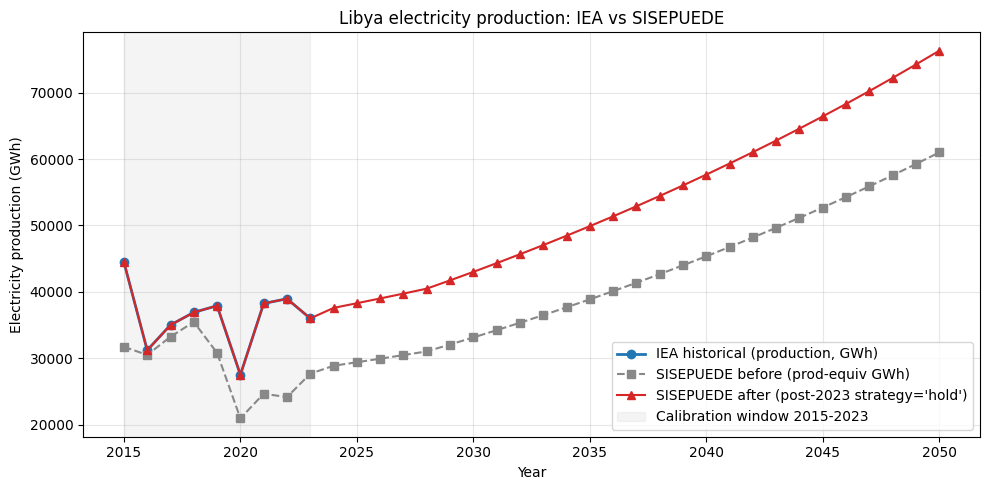

In [9]:
import matplotlib.pyplot as plt

# Full projection 2015 -> TERMINAL_YEAR for before and after
full_before = split_elec_by_sector(df_out_base)
full_before = full_before[(full_before['year'] >= CALIB_YEAR_START) & (full_before['year'] <= TERMINAL_YEAR)]
full_after  = split_elec_by_sector(df_out_new)
full_after  = full_after[(full_after['year'] >= CALIB_YEAR_START) & (full_after['year'] <= TERMINAL_YEAR)]

def prod_equiv(df_elec):
    years = df_elec['year'].astype(int).tolist()
    return years, [(float(df_elec.loc[df_elec['year']==y, 'total'].iloc[0])
                    / max(1e-9, 1.0 - loss_by_year.get(y, 0.0))) * PJ_TO_GWH
                   for y in years]

years_b, before_prod = prod_equiv(full_before)
years_a, after_prod  = prod_equiv(full_after)
iea_years = compare['year'].astype(int).tolist()
iea_plot  = compare['iea_gwh'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iea_years, iea_plot,      marker='o', lw=2, color='#1f77b4',
        label='IEA historical (production, GWh)')
ax.plot(years_b, before_prod,     marker='s', ls='--', color='#888',
        label='SISEPUEDE before (prod-equiv GWh)')
ax.plot(years_a, after_prod,      marker='^', color='#d62728',
        label=f'SISEPUEDE after (post-{CALIB_YEAR_END} strategy={POST_CALIB_STRATEGY!r})')
ax.axvspan(CALIB_YEAR_START, CALIB_YEAR_END, color='#cccccc', alpha=0.2,
           label=f'Calibration window {CALIB_YEAR_START}-{CALIB_YEAR_END}')
ax.set_title('Libya electricity production: IEA vs SISEPUEDE')
ax.set_xlabel('Year'); ax.set_ylabel('Electricity production (GWh)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Notes

- Only **SCOE scalar columns** are touched. INEN consumpinit columns (set by `recalibrate_inen_energy_demand.ipynb`), IPPU production, CCSQ and TRNS inputs remain untouched.
- The default input is the INEN-recalibrated CSV, so running this notebook after `recalibrate_inen_energy_demand.ipynb` **stacks both calibrations** into a separate output (`sisepuede_raw_inputs_recalibrated_electricity.csv`).
- The calibration writes **per-year scalars** for 2015-2023. For 2024+ the behavior is governed by `POST_CALIB_STRATEGY`:
  - `"hold"` (default) - keeps the 2023 scalar flat through 2050. Treats SCOE as structurally understated in the base input and avoids the step-down cliff visible in dispatch/production charts when the scalar resets to 1.0 at 2024.
  - `"linear_to_1"` - fades linearly from the 2023 value back to 1.0 over `POST_CALIB_FADE_YEARS`. Useful if you believe the gap is a historical artifact that the base projection would resolve on its own.
  - `"reset"` - reverts to 1.0 at 2024. This reproduces the original cliff; kept for diagnostics.
- The scalar is clamped to `[F_SCOE_MIN, F_SCOE_MAX]`. If you hit the clamp, the verification assertion will fail - either widen the clamp or revisit whether fixing only SCOE is enough (e.g. also scale INEN or the transmission-loss assumption).
- The transmission-loss column is `frac_enfu_transmission_loss_fuel_electricity` (defaults to 0.20 on the Libya input). Override it with `TRANSMISSION_LOSS_OVERRIDE` if you have a better source.